In [1]:
pip install matplotlib yfinance networkx scipy

Note: you may need to restart the kernel to use updated packages.


[*********************100%***********************]  10 of 10 completed


Running rolling backtest over 1005 days...


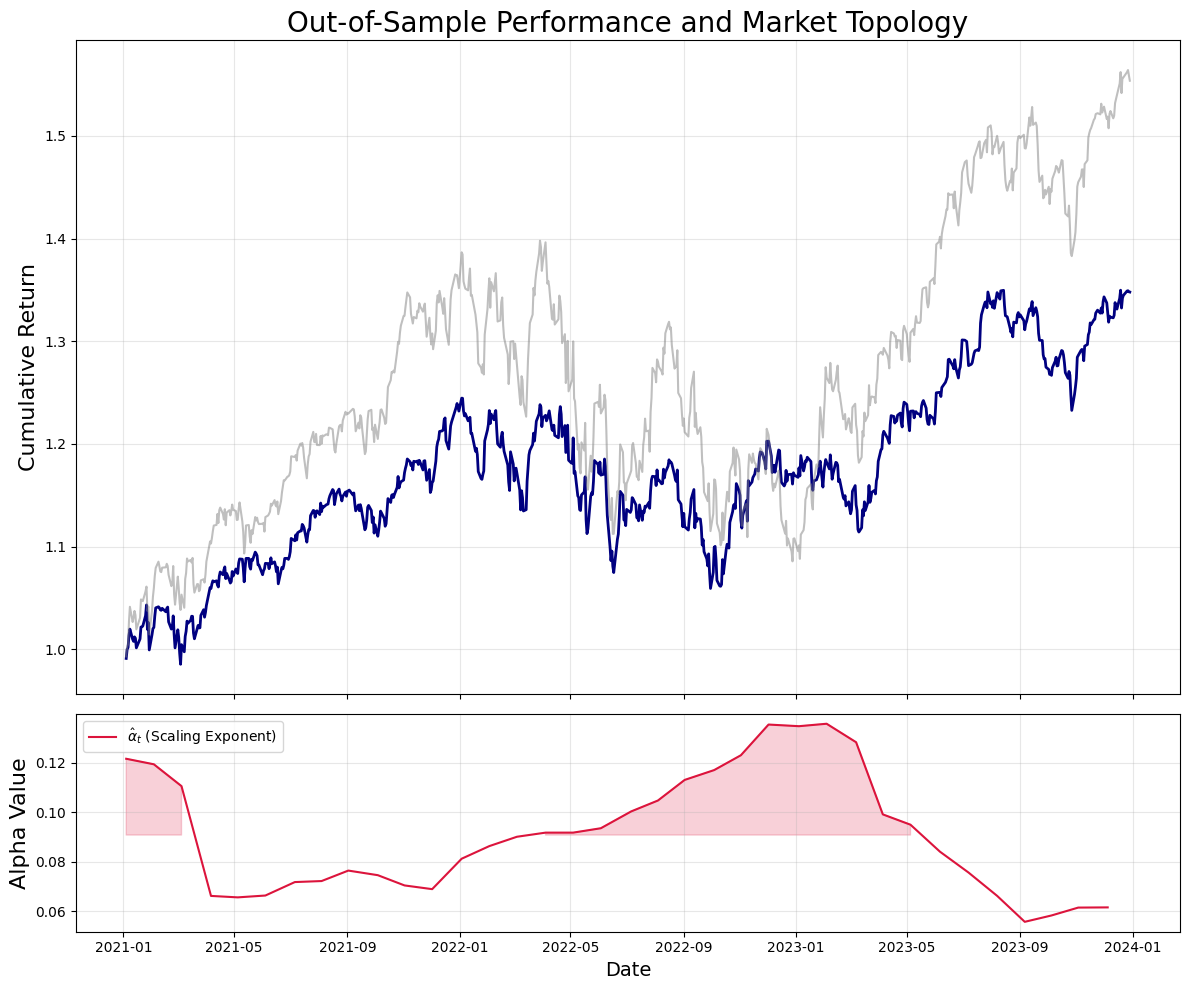

In [2]:
import sys
import os
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# ensure we can import the local padic_portfolio package
sys.path.append(os.path.abspath('..'))
import padic_portfolio.topology.metric as topo
import padic_portfolio.allocation.hrp as alloc

# data
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'JPM', 'JNJ', 'V', 'PG', 'XOM', 'TSLA']
prices = yf.download(tickers, start='2020-01-01', end='2024-01-01')['Close']
returns = prices.pct_change().dropna()

# backtest setup
lookback = 252  
step = 21       

strat_rets = []
bench_rets = []
alphas = [] #store scaling exponents

print(f"Running rolling backtest over {len(returns)} days...")

# main loop 
for t in range(lookback, len(returns), step):
    
    # 1. In-sample window 
    window = returns.iloc[t - lookback : t]
    corr = window.corr()
    
    # 2. topology and scaling exponent
    dist = topo.correlation_to_distance(corr)
    
    #single linkage cluster
    linkage_mat = topo.execute_slc(dist)

    #extract ultrametric structure
    ultra = topo.extract_ultrametric(linkage_mat, corr.columns)
    
    #calculate alpha_t for window
    alpha_t, r2_t = topo.calculate_scaling_exponent(linkage_mat, p=2)
    alphas.append({'date': returns.index[t], 'alpha': alpha_t})

    #3. allocation
    w_series = alloc.allocate_hrp(ultra, window)
    w = w_series.reindex(corr.columns).fillna(0).values 
    
    #4. out-of-sample forward returns
    forward = returns.iloc[t : t + step]
    

    #5. strategy
    strat_wealth = (1 + forward).cumprod() * w
    strat_port_wealth = strat_wealth.sum(axis=1)
    strat_ret = strat_port_wealth.pct_change()
    strat_ret.iloc[0] = strat_port_wealth.iloc[0] - 1.0 # First day return
    strat_rets.extend(strat_ret)
    
    #benchmark (equal weight)
    w_eq = np.ones(len(tickers)) / len(tickers)
    bench_wealth = (1 + forward).cumprod() * w_eq
    bench_port_wealth = bench_wealth.sum(axis=1)
    bench_ret = bench_port_wealth.pct_change()
    bench_ret.iloc[0] = bench_port_wealth.iloc[0] - 1.0 # First day return
    bench_rets.extend(bench_ret)

# plot
idx = returns.index[lookback : lookback + len(strat_rets)]
strat_cum = (1 + pd.Series(strat_rets, index=idx)).cumprod()
bench_cum = (1 + pd.Series(bench_rets, index=idx)).cumprod()

alpha_df = pd.DataFrame(alphas).set_index('date')

#dual panel plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,10), sharex=True, gridspec_kw={'height_ratios': [3,1]})

#plot 1: wealth curves
ax1.plot(strat_cum, label='p-adic HRP', color='navy', lw=2)
ax1.plot(bench_cum, label='Equal Weight', color='gray', alpha=0.5)
ax1.set_title('Out-of-Sample Performance and Market Topology', fontsize=20)
ax1.set_ylabel('Cumulative Return', fontsize=16)
ax1.grid(True, alpha=0.3)

#plot 2: scaling exponent
ax2.plot(alpha_df['alpha'], color='crimson', lw=1.5, label=r'$\hat{\alpha}_t$ (Scaling Exponent)')
ax2.set_ylabel('Alpha Value', fontsize=16)
ax2.set_xlabel('Date', fontsize=14)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

# Highlight: If alpha is above its mean, shade the area (Market Stress Indicator)
mean_alpha = alpha_df['alpha'].mean()
ax2.fill_between(alpha_df.index, alpha_df['alpha'], mean_alpha, 
                 where=(alpha_df['alpha'] > mean_alpha), color='crimson', alpha=0.2)

plt.tight_layout()
plt.show()

In [3]:
# 5. Risk-Adjusted Performance Metrics

def calculate_metrics(returns_series):
    # Annualized Return (assuming 252 trading days)
    ann_ret = returns_series.mean() * 252
    
    # Annualized Volatility
    ann_vol = returns_series.std() * np.sqrt(252)
    
    # Sharpe Ratio (assuming 0% risk-free rate for simplicity)
    sharpe = ann_ret / ann_vol if ann_vol != 0 else 0
    
    # Maximum Drawdown
    cum_wealth = (1 + returns_series).cumprod()
    rolling_max = cum_wealth.cummax()
    drawdown = (cum_wealth - rolling_max) / rolling_max
    max_dd = drawdown.min()
    
    return ann_ret, ann_vol, sharpe, max_dd

# Convert the raw lists into Pandas Series using the 'idx' from the previous cell
strat_series_clean = pd.Series(strat_rets, index=idx)
bench_series_clean = pd.Series(bench_rets, index=idx)

# Calculate metrics for both strategies
strat_metrics = calculate_metrics(strat_series_clean)
bench_metrics = calculate_metrics(bench_series_clean)

# Format the output table
metrics_df = pd.DataFrame({
    'p-adic HRP': strat_metrics,
    'Equal Weight': bench_metrics
}, index=['Ann. Return', 'Ann. Volatility', 'Sharpe Ratio', 'Max Drawdown'])

print("\n--- Out-of-Sample Performance Metrics ---")
print(metrics_df.round(4))


--- Out-of-Sample Performance Metrics ---
                 p-adic HRP  Equal Weight
Ann. Return          0.1097        0.1660
Ann. Volatility      0.1401        0.1921
Sharpe Ratio         0.7833        0.8639
Max Drawdown        -0.1490       -0.2234
